In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

In [2]:
from google.colab import files
uploaded = files.upload()

Saving archive (10).zip to archive (10).zip


In [4]:
import io
import zipfile

# Get the uploaded zip file content. Assuming 'archive (10).zip' is the key.
zip_content = uploaded['archive (10).zip']
zip_file_object = io.BytesIO(zip_content)

# Extract the CSV from the zip file
with zipfile.ZipFile(zip_file_object, 'r') as z:
    # Find the first CSV file within the zip archive
    csv_files = [name for name in z.namelist() if name.endswith('.csv')]
    if not csv_files:
        raise ValueError("No CSV file found in the zip archive.")
    csv_filename_in_zip = csv_files[0]

    # Read the CSV file into a pandas DataFrame
    with z.open(csv_filename_in_zip) as f:
        df = pd.read_csv(f)

print(df.head())

print("\nDataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

In [5]:
print("\nNull Values:")
print(df.isnull().sum())


Null Values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [6]:
print("Before:", df.shape)

df = df.drop_duplicates()

print("After:", df.shape)

Before: (1599, 12)
After: (1359, 12)


In [7]:
numeric = df.select_dtypes(include=np.number)

Q1 = numeric.quantile(0.25)
Q3 = numeric.quantile(0.75)

IQR = Q3 - Q1

outliers = ((numeric < (Q1 - 1.5 * IQR)) |
            (numeric > (Q3 + 1.5 * IQR)))

print("Outliers in each column:")
print(outliers.sum())

Outliers in each column:
fixed acidity            41
volatile acidity         19
citric acid               1
residual sugar          126
chlorides                87
free sulfur dioxide      26
total sulfur dioxide     45
density                  35
pH                       28
sulphates                55
alcohol                  12
quality                  27
dtype: int64


In [8]:
print("Mean")
print(df.mean(numeric_only=True))

print("\nMedian")
print(df.median(numeric_only=True))

print("\nVariance")
print(df.var(numeric_only=True))

print("\nStandard Deviation")
print(df.std(numeric_only=True))

Mean
fixed acidity            8.310596
volatile acidity         0.529478
citric acid              0.272333
residual sugar           2.523400
chlorides                0.088124
free sulfur dioxide     15.893304
total sulfur dioxide    46.825975
density                  0.996709
pH                       3.309787
sulphates                0.658705
alcohol                 10.432315
quality                  5.623252
dtype: float64

Median
fixed acidity            7.9000
volatile acidity         0.5200
citric acid              0.2600
residual sugar           2.2000
chlorides                0.0790
free sulfur dioxide     14.0000
total sulfur dioxide    38.0000
density                  0.9967
pH                       3.3100
sulphates                0.6200
alcohol                 10.2000
quality                  6.0000
dtype: float64

Variance
fixed acidity              3.017134
volatile acidity           0.033500
citric acid                0.038235
residual sugar             1.828752
chlorides  

In [9]:
scaler = MinMaxScaler()

df_normalized = df.copy()

num_cols = df.select_dtypes(include=np.number).columns

df_normalized[num_cols] = scaler.fit_transform(df[num_cols])

print(df_normalized.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0       0.247788          0.397260         0.00        0.068493   0.106845   
1       0.283186          0.520548         0.00        0.116438   0.143573   
2       0.283186          0.438356         0.04        0.095890   0.133556   
3       0.584071          0.109589         0.56        0.068493   0.105175   
5       0.247788          0.369863         0.00        0.061644   0.105175   

   free sulfur dioxide  total sulfur dioxide   density        pH  sulphates  \
0             0.140845              0.098940  0.567548  0.606299   0.137725   
1             0.338028              0.215548  0.494126  0.362205   0.209581   
2             0.197183              0.169611  0.508811  0.409449   0.191617   
3             0.225352              0.190813  0.582232  0.330709   0.149701   
5             0.169014              0.120141  0.567548  0.606299   0.137725   

    alcohol  quality  
0  0.153846      0.4  
1  0.21538

In [10]:
high_alcohol = df[df['alcohol'] > 12]

print(high_alcohol.head())

print("Total Wines:", len(high_alcohol))

     fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
45             4.6             0.520         0.15             2.1      0.054   
95             4.7             0.600         0.17             2.3      0.058   
131            5.6             0.500         0.09             2.3      0.049   
142            5.2             0.340         0.00             1.8      0.050   
198            5.4             0.835         0.08             1.2      0.046   

     free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
45                   8.0                  65.0   0.9934  3.90       0.56   
95                  17.0                 106.0   0.9932  3.85       0.60   
131                 17.0                  99.0   0.9937  3.63       0.63   
142                 27.0                  63.0   0.9916  3.68       0.79   
198                 13.0                  93.0   0.9924  3.57       0.85   

     alcohol  quality  
45      13.1        4  
95      12.9  

In [11]:
group_quality = df.groupby("quality").mean(numeric_only=True)

print(group_quality)

         fixed acidity  volatile acidity  citric acid  residual sugar  \
quality                                                                 
3             8.360000          0.884500     0.171000        2.635000   
4             7.779245          0.693962     0.174151        2.694340   
5             8.171231          0.578596     0.244523        2.509532   
6             8.337383          0.496084     0.279364        2.457290   
7             8.858683          0.403653     0.371856        2.716766   
8             8.441176          0.427647     0.382941        2.576471   

         chlorides  free sulfur dioxide  total sulfur dioxide   density  \
quality                                                                   
3         0.122500            11.000000             24.900000  0.997464   
4         0.090679            12.264151             36.245283  0.996542   
5         0.093971            17.161179             57.406412  0.997082   
6         0.085075            15.637383 

In [12]:
print("Average Fixed Acidity:", df['fixed acidity'].mean())

Average Fixed Acidity: 8.310596026490067


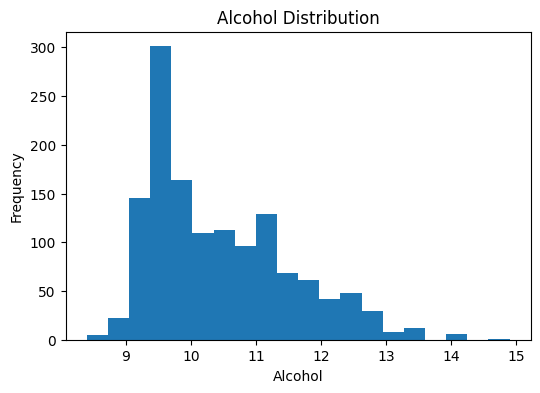

In [13]:
plt.figure(figsize=(6,4))

plt.hist(df['alcohol'], bins=20)

plt.title("Alcohol Distribution")

plt.xlabel("Alcohol")

plt.ylabel("Frequency")

plt.show()

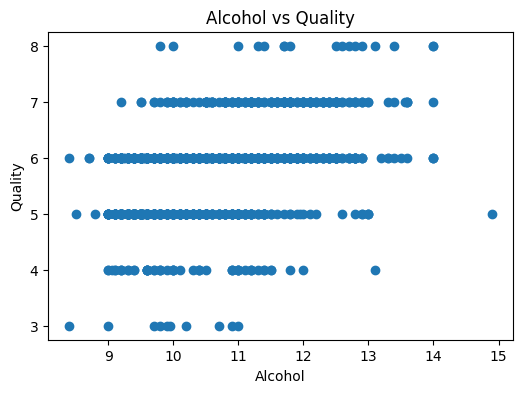

In [14]:
plt.figure(figsize=(6,4))

plt.scatter(df['alcohol'], df['quality'])

plt.title("Alcohol vs Quality")

plt.xlabel("Alcohol")

plt.ylabel("Quality")

plt.show()

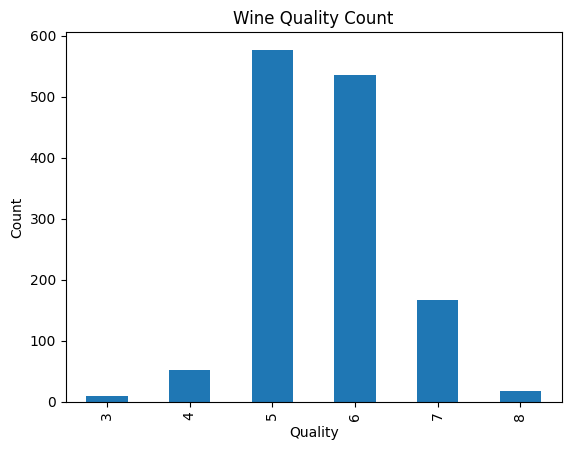

In [15]:
df['quality'].value_counts().sort_index().plot(kind='bar')

plt.title("Wine Quality Count")

plt.xlabel("Quality")

plt.ylabel("Count")

plt.show()

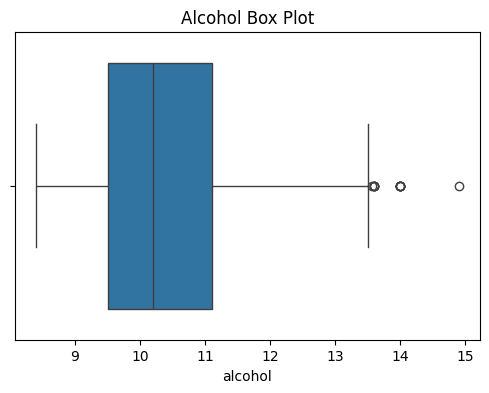

In [16]:
plt.figure(figsize=(6,4))

sns.boxplot(x=df['alcohol'])

plt.title("Alcohol Box Plot")

plt.show()

In [17]:
print("""
EDA SUMMARY

1. Dataset loaded successfully.
2. Null values checked.
3. Duplicate records removed.
4. Outliers detected using IQR.
5. Mean, Median, Variance and Standard Deviation calculated.
6. Numerical columns normalized using MinMaxScaler.
7. Wines with alcohol greater than 12 filtered.
8. Data grouped by quality.
9. Average fixed acidity calculated.
10. Histogram, Scatter Plot, Bar Chart and Box Plot created.
""")


EDA SUMMARY

1. Dataset loaded successfully.
2. Null values checked.
3. Duplicate records removed.
4. Outliers detected using IQR.
5. Mean, Median, Variance and Standard Deviation calculated.
6. Numerical columns normalized using MinMaxScaler.
7. Wines with alcohol greater than 12 filtered.
8. Data grouped by quality.
9. Average fixed acidity calculated.
10. Histogram, Scatter Plot, Bar Chart and Box Plot created.

